# CX doesn not begin only at fulfillment (Small Aggregate Extension)

In [1]:
import pandas as pd
from pathlib import Path

# Define path (adjust if needed)
FUNNEL_PATH = Path("../data/raw/Marketing Funnel")

# Load datasets
leads = pd.read_csv(FUNNEL_PATH / "olist_marketing_qualified_leads_dataset.csv")
deals = pd.read_csv(FUNNEL_PATH / "olist_closed_deals_dataset.csv")

In [2]:
import sys
sys.path.append("..")  # adjust if needed

from utils import *

In [3]:
leads.head()
deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [4]:
df_marketing = leads.merge(deals, on="mql_id", how="left")

In [5]:
df_marketing["converted"] = df_marketing["declared_monthly_revenue"].notna().astype(int)

In [6]:
conversion = (
    df_marketing.groupby("origin")["converted"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

conversion

origin
unknown              16.287534
paid_search          12.295082
organic_search       11.803136
direct_traffic       11.222445
referral              8.450704
social                5.555556
display               5.084746
other_publicities     4.615385
email                 3.042596
other                 2.666667
Name: converted, dtype: float64

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61328/4046981298.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=30, ha="right")


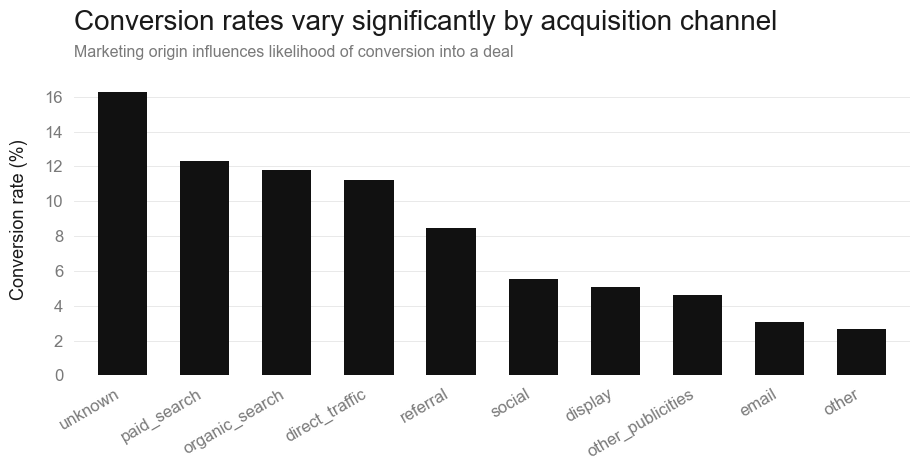

In [7]:
fig, ax = create_figure(figsize=(10, 5.5))

x = conversion.index
y = conversion.values

bars = ax.bar(x, y, color=ACCENT, width=0.6)

add_title(
    ax,
    "Conversion rates vary significantly by acquisition channel",
    "Marketing origin influences likelihood of conversion into a deal"
)

ax.set_ylabel("Conversion rate (%)")
ax.set_xticklabels(x, rotation=30, ha="right")

clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()

## Connecting Marketing and Customer Experience

While the marketing and e-commerce datasets are not directly linked at the customer level, the analysis suggests that acquisition channels may influence customer expectations and perceived experience quality.

Channels with higher conversion rates may attract customers with different expectations, which could impact downstream satisfaction and retention.

Due to the lack of a shared customer identifier, this analysis is conducted at an aggregate level and should be interpreted as directional rather than causal.